Fetching Open-Meteo hourly data for Montreal, QC...
Preprocessing data...

===== Model Performance =====
Training RMSE:  0.619 °C
Training MAE:   0.424 °C
Validation RMSE:0.631 °C
Validation MAE: 0.461 °C

===== Baseline Performance (Persistence) =====
Baseline RMSE:  0.799 °C
Baseline MAE:   0.579 °C


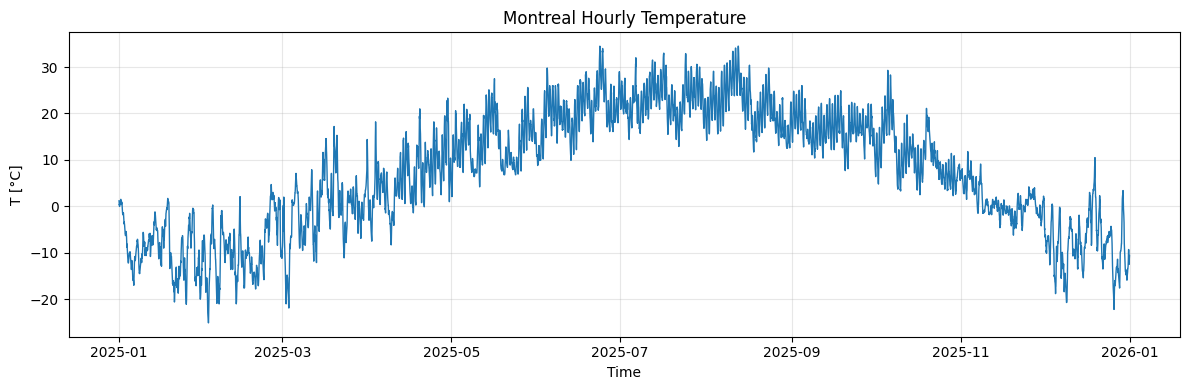

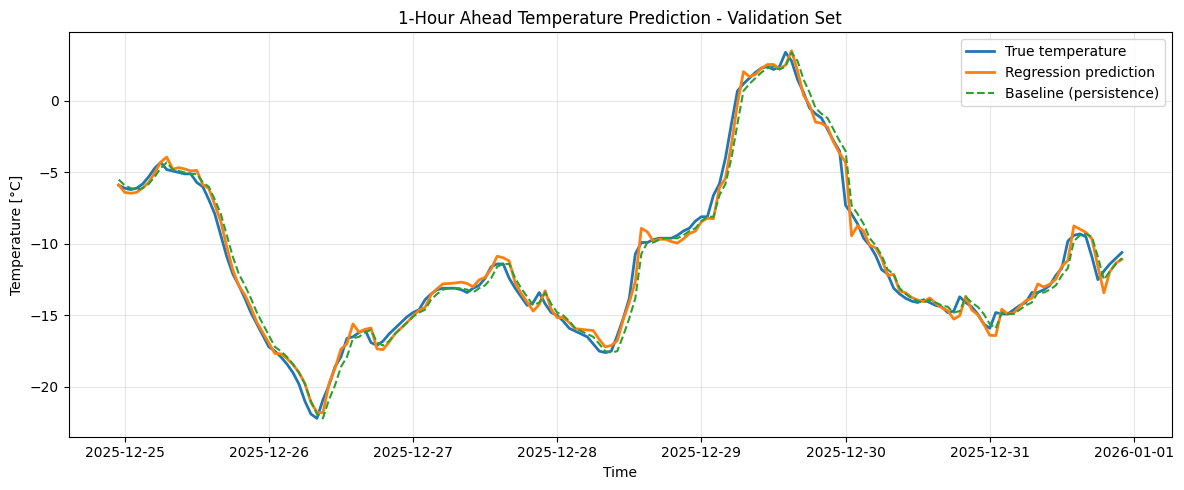


===== Learned Coefficients =====
  feature  coefficient
intercept     0.275390
        T     1.430783
        W    -0.022131
  sin_day     0.167612
  cos_day    -0.303308
 sin_year    -0.081775
 cos_year    -0.269736
   T_lag1    -0.362082
   T_lag2    -0.073504
   T_lag3    -0.023328
   T_lag6     0.005477
  T_lag12     0.012136
  T_lag24    -0.008138
   W_lag1     0.004888
   W_lag2     0.009965
   W_lag6    -0.001321
  W_lag12    -0.005881
  W_lag24     0.001291


In [1]:
# ================================
# MECH 309 - Part 1 Starter-Based Solution
# 1-hour ahead temperature prediction for Montreal
# ================================

!pip -q install numpy pandas matplotlib requests

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt


# -------------------------------
# 1) Location class and Montreal data
# -------------------------------
@dataclass(frozen=True)
class Location:
    name: str
    lat: float
    lon: float
    timezone: str


MONTREAL = Location(
    name="Montreal, QC",
    lat=45.5017,
    lon=-73.5673,
    timezone="America/Montreal",
)


# -------------------------------
# 2) Fetch hourly weather data from Open-Meteo
# -------------------------------
def fetch_open_meteo_hourly(
    start_date: str,
    end_date: str,
    location: Location = MONTREAL,
    hourly_vars: List[str] | None = None,
) -> pd.DataFrame:
    if hourly_vars is None:
        hourly_vars = [
            "temperature_2m",
            "wind_speed_10m",
            "wind_direction_10m",
            "relative_humidity_2m",
            "surface_pressure",
            "precipitation",
            "cloud_cover",
        ]

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": location.lat,
        "longitude": location.lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(hourly_vars),
        "timezone": location.timezone,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    hourly = payload.get("hourly", {})
    times = hourly.get("time", None)
    if times is None:
        raise RuntimeError("Open-Meteo response missing hourly time.")

    idx = pd.to_datetime(times)
    df = pd.DataFrame(index=idx)

    for k, v in hourly.items():
        if k == "time":
            continue
        df[k] = v

    df.index.name = "time_local"
    return df


# -------------------------------
# 3) Preprocess data and add cyclical features
# -------------------------------
def preprocess(df: pd.DataFrame) -> pd.DataFrame:

  """
    Cleans the raw weather data and adds time-based features.

    Main tasks:
    - sort time
    - remove duplicates
    - fill missing hourly timestamps
    - interpolate/fill missing values
    - rename columns to shorter names
    - add daily and yearly sinusoidal features
    """

    # Sort timestamps and remove duplicates
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]

    # Reindex to a complete hourly grid
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq="h", tz=df.index.tz)
    df = df.reindex(full_idx)

    # Fill small gaps by interpolation, then forward/back fill
    df = df.interpolate(limit=6)
    df = df.ffill().bfill()

    # Rename columns to shorter names
    rename = {
        "temperature_2m": "T",
        "wind_speed_10m": "W",
        "wind_direction_10m": "Wd",
        "relative_humidity_2m": "RH",
        "surface_pressure": "P",
        "precipitation": "Prec",
        "cloud_cover": "Cloud",
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    # Daily cycle features
    # Extract the hour of day: 0, 1, 2, ..., 23
    hour = df.index.hour.to_numpy()

    # Angular frequency for a 24-hour cycle
    omega_day = 2 * math.pi / 24.0

    # sin_day and cos_day encode the time of day smoothly
    # This is better than using hour directly because hour is cyclic
    df["sin_day"] = np.sin(omega_day * hour)
    df["cos_day"] = np.cos(omega_day * hour)

    # Yearly / seasonal cycle features
    # Extract day of year: 1 to 365 (or 366)
    doy = df.index.dayofyear.to_numpy()

    # Angular frequency for one full year
    omega_year = 2 * math.pi / 365.25

    # sin_year and cos_year help capture seasonal variation
    # Example: winter vs summer behavior
    df["sin_year"] = np.sin(omega_year * doy)
    df["cos_year"] = np.cos(omega_year * doy)

    # Return the cleaned + enriched DataFrame
    return df


# -------------------------------
# 4) Add lagged features
# -------------------------------
def add_lags(df: pd.DataFrame, col: str, lags: List[int]) -> pd.DataFrame:
    """
    Adds lagged copies of a column.

    Example:
        if col = "T" and lags = [1, 2],
        it creates:
            T_lag1 = T shifted by 1 hour
            T_lag2 = T shifted by 2 hours

    This gives the model access to past values.
    """

    # Loop over each lag value requested
    for L in lags:
        # Ignore zero or negative lags just in case
        if L <= 0:
            continue

        # shift(L) moves the series downward by L rows
        # so row k gets the value from row k-L
        df[f"{col}_lag{L}"] = df[col].shift(L)

    # Return DataFrame with new lag columns added
    return df


# -------------------------------
# 5) Train / validation split
# -------------------------------
def split_train_val(data: pd.DataFrame, val_hours: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Splits the time series into:
    - training set: earlier data
    - validation set: most recent data

    We keep the final val_hours points for validation.
    """

    if len(data) <= val_hours + 10:
        raise ValueError("Not enough samples for requested validation window.")
    return data.iloc[:-val_hours].copy(), data.iloc[-val_hours:].copy()


# -------------------------------
# 6) Error metrics
# -------------------------------
def rmse(y_true, y_pred):
    """
    Root Mean Square Error:
    measures average prediction error with stronger penalty on large errors
    """
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    """
    Mean Absolute Error:
    average absolute difference between prediction and truth
    """
    return np.mean(np.abs(y_true - y_pred))

# -------------------------------
# 7) Main workflow
# -------------------------------
# You can change these dates later
start_date = "2025-01-01"
end_date   = "2025-12-31"

print(f"Fetching Open-Meteo hourly data for {MONTREAL.name}...")
df_raw = fetch_open_meteo_hourly(start_date, end_date, location=MONTREAL)

print("Preprocessing data...")
df = preprocess(df_raw)

# Add lagged temperature and wind predictors
# These help the regression use recent history
temp_lags = [1, 2, 3, 6, 12, 24]
wind_lags = [1, 2, 6, 12, 24]

df = add_lags(df, "T", temp_lags)
df = add_lags(df, "W", wind_lags)

# Forecast horizon: 1 hour ahead
h = 1
df["T_target"] = df["T"].shift(-h)

# Remove rows with NaNs caused by lagging and shifting
df_model = df.dropna().copy()

# Choose model input columns
feature_cols = [
    "T", "W",
    "sin_day", "cos_day",
    "sin_year", "cos_year",
    "T_lag1", "T_lag2", "T_lag3", "T_lag6", "T_lag12", "T_lag24",
    "W_lag1", "W_lag2", "W_lag6", "W_lag12", "W_lag24",
]

target_col = "T_target"

# Validation = last 7 days
val_hours = 24 * 7
train_df, val_df = split_train_val(df_model, val_hours)

# Build design matrices
# Extract training predictors
X_train = train_df[feature_cols].to_numpy()

# Extract training targets
y_train = train_df[target_col].to_numpy()

# Extract validation predictors
X_val = val_df[feature_cols].to_numpy()

# Extract validation targets
y_val = val_df[target_col].to_numpy()

# Add intercept column
X_train = np.column_stack([np.ones(len(X_train)), X_train])
X_val   = np.column_stack([np.ones(len(X_val)), X_val])

# Solve least-squares problem: min ||X theta - y||^2

# theta contains the model coefficients.
# np.linalg.lstsq is numerically safer than manually computing (X^T X)^(-1) X^T y
theta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)

# Predictions
yhat_train = X_train @ theta
yhat_val = X_val @ theta

# Baseline model: persistence
# For 1-hour ahead forecast, baseline says future temp ≈ current temp
baseline_val = val_df["T"].to_numpy()

# Metrics

# Training Errors
train_rmse = rmse(y_train, yhat_train)
train_mae = mae(y_train, yhat_train)

# Validation Errors
val_rmse = rmse(y_val, yhat_val)
val_mae = mae(y_val, yhat_val)

# Baseline Errors
baseline_rmse = rmse(y_val, baseline_val)
baseline_mae = mae(y_val, baseline_val)

# -------------------------------
# 8) Print results
# -------------------------------
print("\n===== Model Performance =====")
print(f"Training RMSE:  {train_rmse:.3f} °C")
print(f"Training MAE:   {train_mae:.3f} °C")
print(f"Validation RMSE:{val_rmse:.3f} °C")
print(f"Validation MAE: {val_mae:.3f} °C")

print("\n===== Baseline Performance (Persistence) =====")
print(f"Baseline RMSE:  {baseline_rmse:.3f} °C")
print(f"Baseline MAE:   {baseline_mae:.3f} °C")

# -------------------------------
# 9) Plot raw temperature data
# -------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["T"], linewidth=1)
plt.title("Montreal Hourly Temperature")
plt.ylabel("T [°C]")
plt.xlabel("Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------
# 10) Plot validation predictions
# -------------------------------
plt.figure(figsize=(12, 5))
plt.plot(val_df.index, y_val, label="True temperature", linewidth=2)
plt.plot(val_df.index, yhat_val, label="Regression prediction", linewidth=2)
plt.plot(val_df.index, baseline_val, "--", label="Baseline (persistence)", linewidth=1.5)
plt.title("1-Hour Ahead Temperature Prediction - Validation Set")
plt.ylabel("Temperature [°C]")
plt.xlabel("Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------
# 11) Show learned coefficients
# -------------------------------
coef_names = ["intercept"] + feature_cols
coef_table = pd.DataFrame({
    "feature": coef_names,
    "coefficient": theta
})

print("\n===== Learned Coefficients =====")
print(coef_table.to_string(index=False))


===== Multi-Horizon Results =====
h=1h | RMSE=0.631 | Baseline=0.799 | Improvement=21.1%
h=6h | RMSE=3.232 | Baseline=3.502 | Improvement=7.7%
h=12h | RMSE=5.365 | Baseline=5.894 | Improvement=9.0%
h=24h | RMSE=6.385 | Baseline=8.803 | Improvement=27.5%


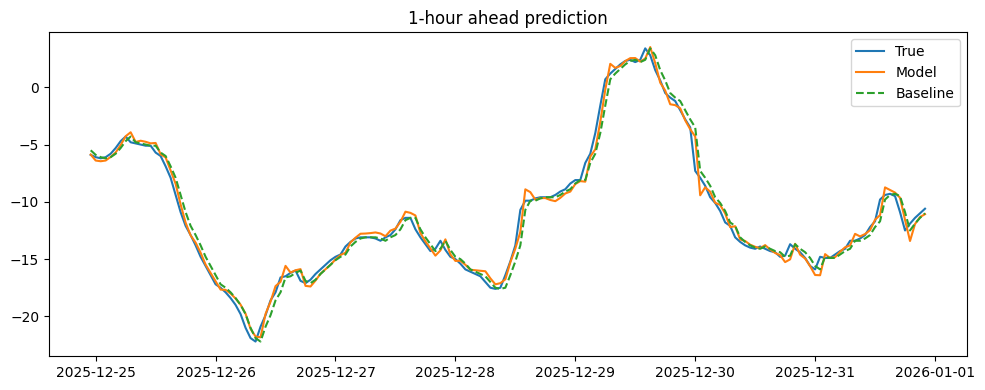

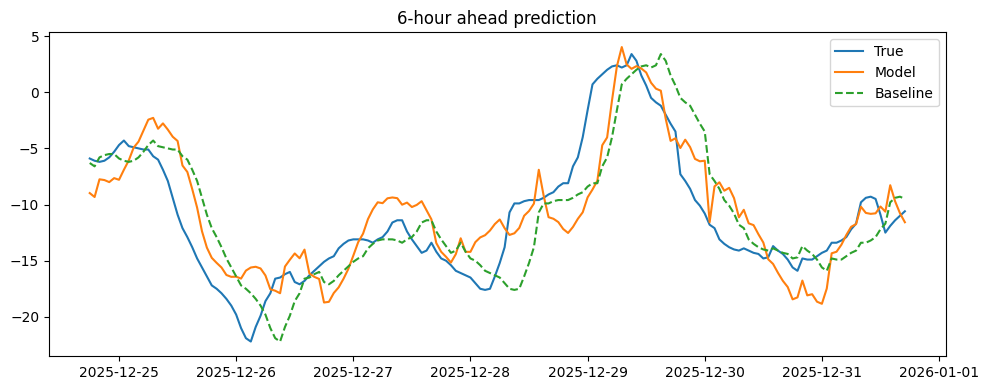

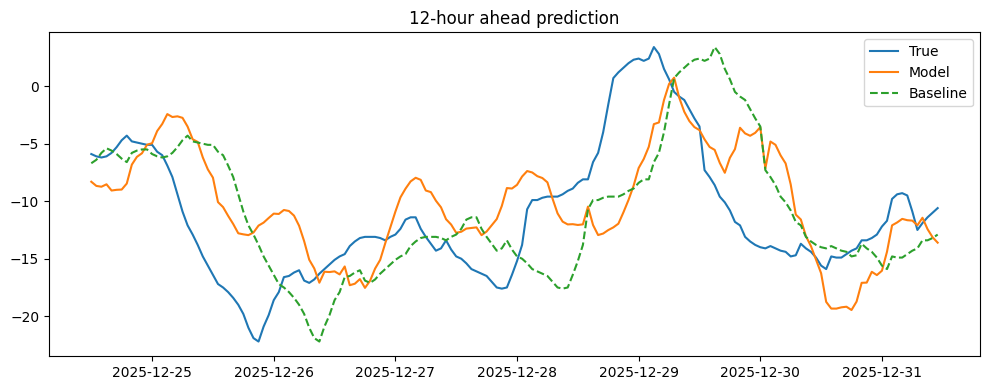

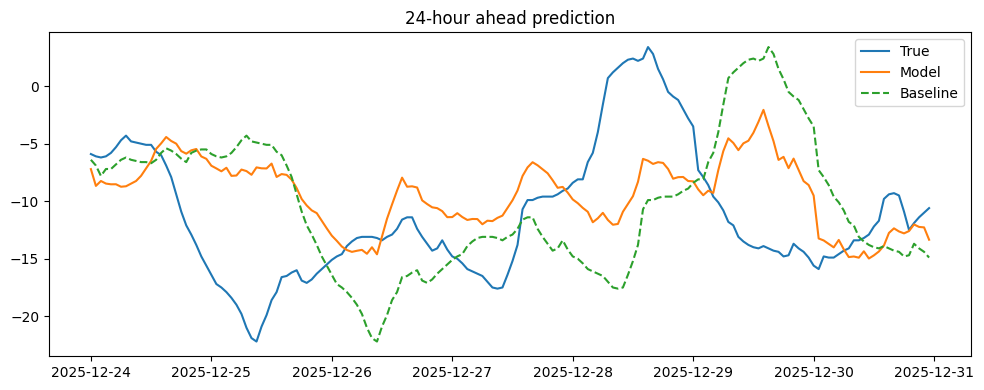

In [2]:
# ================================
# MECH 309 - Part 1
# Multi-horizon temperature prediction (1h, 6h, 12h, 24h)
# ================================

!pip -q install numpy pandas matplotlib requests

from __future__ import annotations
import math
from dataclasses import dataclass
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt


# -------------------------------
# Location definition
# -------------------------------
@dataclass(frozen=True)
class Location:
    name: str
    lat: float
    lon: float
    timezone: str


MONTREAL = Location(
    name="Montreal, QC",
    lat=45.5017,
    lon=-73.5673,
    timezone="America/Montreal",
)


# -------------------------------
# Fetch hourly weather data
# -------------------------------
def fetch_open_meteo_hourly(start_date, end_date, location=MONTREAL):

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": location.lat,
        "longitude": location.lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,wind_speed_10m",
        "timezone": location.timezone,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    hourly = payload["hourly"]
    idx = pd.to_datetime(hourly["time"])

    df = pd.DataFrame(index=idx)
    df["T"] = hourly["temperature_2m"]
    df["W"] = hourly["wind_speed_10m"]

    df.index.name = "time_local"
    return df


# -------------------------------
# Preprocessing + feature construction
# -------------------------------
def preprocess(df):

    # enforce ordered, unique timestamps
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]

    # enforce continuous hourly grid
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq="h", tz=df.index.tz)
    df = df.reindex(full_idx)

    # fill missing values
    df = df.interpolate(limit=6).ffill().bfill()

    # daily periodic features
    hour = df.index.hour.to_numpy()
    omega_day = 2 * math.pi / 24
    df["sin_day"] = np.sin(omega_day * hour)
    df["cos_day"] = np.cos(omega_day * hour)

    # seasonal periodic features
    doy = df.index.dayofyear.to_numpy()
    omega_year = 2 * math.pi / 365.25
    df["sin_year"] = np.sin(omega_year * doy)
    df["cos_year"] = np.cos(omega_year * doy)

    return df


# -------------------------------
# Lagged predictors (autoregressive features)
# -------------------------------
def add_lags(df, col, lags):
    for L in lags:
        if L > 0:
            df[f"{col}_lag{L}"] = df[col].shift(L)
    return df


# -------------------------------
# Time-based train/validation split
# -------------------------------
def split_train_val(data, val_hours):
    return data.iloc[:-val_hours].copy(), data.iloc[-val_hours:].copy()


# -------------------------------
# Error metrics
# -------------------------------
def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat)**2))


# -------------------------------
# Train + evaluate one horizon
# -------------------------------
def run_model(df_base, h, feature_cols):

    # define target: T(k+h)
    df = df_base.copy()
    df["T_target"] = df["T"].shift(-h)

    # remove invalid rows
    df = df.dropna().copy()

    # split into train / validation
    train_df, val_df = split_train_val(df, 24*7)

    # build regression matrices
    X_train = train_df[feature_cols].to_numpy()
    y_train = train_df["T_target"].to_numpy()

    X_val = val_df[feature_cols].to_numpy()
    y_val = val_df["T_target"].to_numpy()

    # add intercept term
    X_train = np.column_stack([np.ones(len(X_train)), X_train])
    X_val   = np.column_stack([np.ones(len(X_val)), X_val])

    # solve least squares: min ||Xθ - y||²
    theta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)

    # predictions
    yhat_val = X_val @ theta

    # baseline: persistence T(k+h) ≈ T(k)
    baseline = val_df["T"].to_numpy()

    return {
        "h": h,
        "rmse_model": rmse(y_val, yhat_val),
        "rmse_baseline": rmse(y_val, baseline),
        "val_index": val_df.index,
        "y_val": y_val,
        "yhat": yhat_val,
        "baseline": baseline
    }


# ================================
# MAIN PIPELINE
# ================================

# 1) Data acquisition
df_raw = fetch_open_meteo_hourly("2025-01-01", "2025-12-31")

# 2) Preprocessing + feature engineering
df = preprocess(df_raw)

# 3) Add autoregressive predictors
df = add_lags(df, "T", [1,2,3,6,12,24])
df = add_lags(df, "W", [1,2,6,12,24])

# 4) Feature set
feature_cols = [
    "T", "W",
    "sin_day", "cos_day",
    "sin_year", "cos_year",
    "T_lag1","T_lag2","T_lag3","T_lag6","T_lag12","T_lag24",
    "W_lag1","W_lag2","W_lag6","W_lag12","W_lag24",
]

# 5) Horizons to evaluate
horizons = [1, 6, 12, 24]

results = []

# 6) Train model for each horizon
for h in horizons:
    res = run_model(df, h, feature_cols)
    results.append(res)

# -------------------------------
# 7) Print summary table
# -------------------------------
print("\n===== Multi-Horizon Results =====")
for r in results:
    improvement = 100*(r["rmse_baseline"] - r["rmse_model"]) / r["rmse_baseline"]
    print(f"h={r['h']}h | RMSE={r['rmse_model']:.3f} | Baseline={r['rmse_baseline']:.3f} | Improvement={improvement:.1f}%")

# -------------------------------
# 8) Plot predictions per horizon
# -------------------------------
for r in results:
    plt.figure(figsize=(10,4))
    plt.plot(r["val_index"], r["y_val"], label="True")
    plt.plot(r["val_index"], r["yhat"], label="Model")
    plt.plot(r["val_index"], r["baseline"], "--", label="Baseline")
    plt.title(f"{r['h']}-hour ahead prediction")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Analysis
